/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

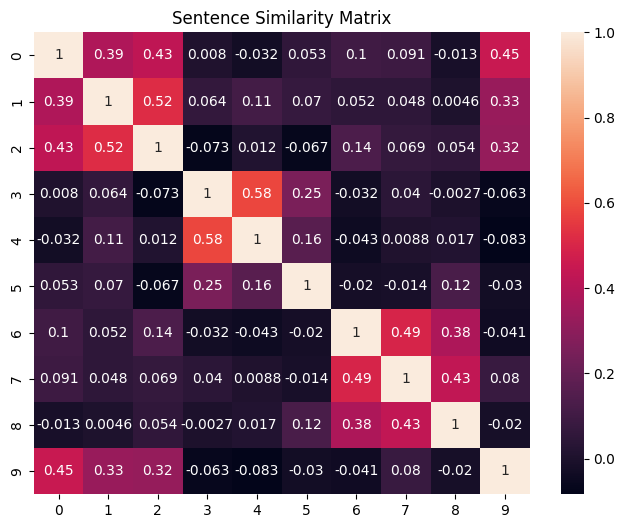

The bowler took three wickets in one over 1.0000001
The batsman hit a powerful cover drive 0.51797247


In [1]:
!pip install sentence-transformers seaborn matplotlib

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [

# Cricket
"Cricket is the most popular sport in India",
"The bowler took three wickets in one over",
"The batsman hit a powerful cover drive",

# Cooking
"Cooking pasta requires boiling water",
"A chef carefully prepared the Italian pasta",
"Baking a cake requires flour and eggs",

# Cybersecurity
"Cybersecurity protects computer systems from attacks",
"Strong passwords improve system security",
"Phishing attacks attempt to steal user credentials",

# extra
"The cricket stadium was full of cheering fans"
]

embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(df, annot=True)
plt.title("Sentence Similarity Matrix")
plt.show()

query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)

top_indices = scores[0].argsort()[-2:][::-1]

for i in top_indices:
    print(sentences[i], scores[0][i])
